# Crime Analysis in India (2001–2013)

This project analyzes crime data across Indian states and districts between 2001 and 2013.

The objective is to explore patterns in crime distribution, identify high-crime regions, understand how crime has evolved over time, and determine which crime categories have experienced the largest growth.

Key questions explored in this analysis include:

- Which states report the highest number of crimes?
- How has crime changed over time in India?
- Which crime categories are most common?
- Which districts report the highest crime levels?
- Which crime types have grown the most between 2001 and 2013?

The analysis uses Python with the following libraries:

- Pandas for data analysis
- NumPy for numerical operations
- Matplotlib and Seaborn for visualization

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview

The dataset contains district-level crime statistics reported under the Indian Penal Code (IPC) from 2001 to 2013.

Each row represents crime statistics for a specific district within a state or union territory for a particular year.

Important columns include:

- **STATE/UT** – State or Union Territory
- **DISTRICT** – District name
- **YEAR** – Year of recorded crimes
- **Crime categories** – Various IPC crime types such as murder, theft, rape, etc.
- **TOTAL IPC CRIMES** – Total crimes recorded for that district in that year

Before performing analysis, we explore the dataset structure and check for potential inconsistencies.

In [146]:
df = pd.read_csv("../data/raw/Crimes_in_india_2001-2013.csv")
df.head()

,STATE/UT,DISTRICT,YEAR,MURDER,ATTEMPT TO MURDER,CULPABLE HOMICIDE NOT AMOUNTING TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,...,ARSON,HURT/GREVIOUS HURT,DOWRY DEATHS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,INSULT TO MODESTY OF WOMEN,CRUELTY BY HUSBAND OR HIS RELATIVES,IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES,CAUSING DEATH BY NEGLIGENCE,OTHER IPC CRIMES,TOTAL IPC CRIMES
0,ANDHRA PRADESH,ADILABAD,2001,101,60,17,50,0,50,46,...,30,1131,16,149,34,175,0,181,1518,4154
1,ANDHRA PRADESH,ANANTAPUR,2001,151,125,1,23,0,23,53,...,69,1543,7,118,24,154,0,270,754,4125
2,ANDHRA PRADESH,CHITTOOR,2001,101,57,2,27,0,27,59,...,38,2088,14,112,83,186,0,404,1262,5818
3,ANDHRA PRADESH,CUDDAPAH,2001,80,53,1,20,0,20,25,...,23,795,17,126,38,57,0,233,1181,3140
4,ANDHRA PRADESH,EAST GODAVARI,2001,82,67,1,23,0,23,49,...,41,1244,12,109,58,247,0,431,2313,6507


## Data Exploration

Initial exploration helps us understand:

- Dataset structure
- Number of columns and data types
- Distribution of values
- Unique states and districts

This step ensures we understand the data before performing analysis.

In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9840 entries, 0 to 9839
Data columns (total 33 columns):
 #   Column                                               Non-Null Count  Dtype
---  ------                                               --------------  -----
 0   STATE/UT                                             9840 non-null   str  
 1   DISTRICT                                             9840 non-null   str  
 2   YEAR                                                 9840 non-null   int64
 3   MURDER                                               9840 non-null   int64
 4   ATTEMPT TO MURDER                                    9840 non-null   int64
 5   CULPABLE HOMICIDE NOT AMOUNTING TO MURDER            9840 non-null   int64
 6   RAPE                                                 9840 non-null   int64
 7   CUSTODIAL RAPE                                       9840 non-null   int64
 8   OTHER RAPE                                           9840 non-null   int64
 9   KIDNAPPING & ABDUCT

In [148]:
df.describe()

,YEAR,MURDER,ATTEMPT TO MURDER,CULPABLE HOMICIDE NOT AMOUNTING TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,KIDNAPPING AND ABDUCTION OF OTHERS,...,ARSON,HURT/GREVIOUS HURT,DOWRY DEATHS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,INSULT TO MODESTY OF WOMEN,CRUELTY BY HUSBAND OR HIS RELATIVES,IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES,CAUSING DEATH BY NEGLIGENCE,OTHER IPC CRIMES,TOTAL IPC CRIMES
count,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000,...,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000,9840.000000
mean,2007.161890,88.565854,78.738618,9.754878,55.456098,0.005488,55.450610,85.836992,64.184553,21.652439,...,25.012398,753.362805,20.179878,106.482520,27.772967,202.046138,0.187602,226.296951,2214.523171,5404.141463
std,3.755581,325.417692,306.650391,58.733349,201.690457,0.111218,201.676202,354.035359,278.536450,93.769371,...,97.601717,3059.322654,97.446611,423.729483,170.367098,869.325453,2.319261,952.900601,8199.391921,18941.271529
min,2001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2004.000000,18.000000,10.000000,0.000000,8.000000,0.000000,8.000000,10.000000,6.000000,2.000000,...,2.000000,43.750000,1.000000,10.000000,0.000000,11.000000,0.000000,5.000000,264.000000,857.750000
50%,2007.000000,37.000000,28.000000,2.000000,21.000000,0.000000,21.000000,26.000000,19.000000,5.000000,...,8.000000,199.000000,5.000000,33.000000,2.000000,49.000000,0.000000,70.000000,750.000000,2130.500000
75%,2010.000000,66.000000,57.000000,6.000000,43.000000,0.000000,43.000000,60.000000,46.000000,14.000000,...,19.000000,533.250000,16.000000,80.000000,13.000000,139.250000,0.000000,180.000000,1631.000000,4025.000000
max,2013.000000,7601.000000,7964.000000,1616.000000,4335.000000,5.000000,4335.000000,11183.000000,9737.000000,2685.000000,...,2830.000000,60488.000000,2335.000000,8252.000000,4970.000000,19865.000000,83.000000,16076.000000,127850.000000,234385.000000


In [149]:
df.columns

Index(['STATE/UT', 'DISTRICT', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'BURGLARY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'RIOTS', 'CRIMINAL BREACH OF TRUST',
       'CHEATING', 'COUNTERFIETING', 'ARSON', 'HURT/GREVIOUS HURT',
       'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES',
       'CAUSING DEATH BY NEGLIGENCE', 'OTHER IPC CRIMES', 'TOTAL IPC CRIMES'],
      dtype='str')

In [150]:
df["STATE/UT"].unique()

<StringArray>
[   'ANDHRA PRADESH', 'ARUNACHAL PRADESH',             'ASSAM',
             'BIHAR',      'CHHATTISGARH',               'GOA',
           'GUJARAT',           'HARYANA',  'HIMACHAL PRADESH',
   'JAMMU & KASHMIR',         'JHARKHAND',         'KARNATAKA',
            'KERALA',    'MADHYA PRADESH',       'MAHARASHTRA',
           'MANIPUR',         'MEGHALAYA',           'MIZORAM',
          'NAGALAND',            'ODISHA',            'PUNJAB',
         'RAJASTHAN',            'SIKKIM',        'TAMIL NADU',
           'TRIPURA',     'UTTAR PRADESH',       'UTTARAKHAND',
       'WEST BENGAL',     'A & N ISLANDS',        'CHANDIGARH',
      'D & N HAVELI',       'DAMAN & DIU',          'DELHI UT',
       'LAKSHADWEEP',        'PUDUCHERRY',    'Andhra Pradesh',
 'Arunachal Pradesh',             'Assam',             'Bihar',
      'Chhattisgarh',               'Goa',           'Gujarat',
           'Haryana',  'Himachal Pradesh',   'Jammu & Kashmir',
         'Jharkhand',     

In [151]:
df["STATE/UT"].nunique()

70

In [152]:
df[df["STATE/UT"] == "Maharashtra"].head()

,STATE/UT,DISTRICT,YEAR,MURDER,ATTEMPT TO MURDER,CULPABLE HOMICIDE NOT AMOUNTING TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,...,ARSON,HURT/GREVIOUS HURT,DOWRY DEATHS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,INSULT TO MODESTY OF WOMEN,CRUELTY BY HUSBAND OR HIS RELATIVES,IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES,CAUSING DEATH BY NEGLIGENCE,OTHER IPC CRIMES,TOTAL IPC CRIMES
9427,Maharashtra,AHMEDNAGAR,2013,112,71,6,105,0,105,81,...,52,759,10,243,34,397,0,733,1879,7934
9428,Maharashtra,AKOLA,2013,35,47,2,46,0,46,31,...,31,942,4,200,35,121,0,118,1059,3979
9429,Maharashtra,AMRAVATI COMMR.,2013,19,41,2,26,0,26,27,...,10,392,2,96,27,38,0,65,901,2776
9430,Maharashtra,AMRAVATI RURAL,2013,55,60,4,78,0,78,53,...,68,1445,1,317,35,175,0,238,1473,5440
9431,Maharashtra,AURANGABAD COMMR.,2013,32,50,0,22,0,22,49,...,29,500,5,173,38,151,0,157,716,4033


In [153]:
sorted(df["STATE/UT"].unique())

['A & N ISLANDS',
 'A&N Islands',
 'ANDHRA PRADESH',
 'ARUNACHAL PRADESH',
 'ASSAM',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'BIHAR',
 'Bihar',
 'CHANDIGARH',
 'CHHATTISGARH',
 'Chandigarh',
 'Chhattisgarh',
 'D & N HAVELI',
 'D&N Haveli',
 'DAMAN & DIU',
 'DELHI UT',
 'Daman & Diu',
 'Delhi UT',
 'GOA',
 'GUJARAT',
 'Goa',
 'Gujarat',
 'HARYANA',
 'HIMACHAL PRADESH',
 'Haryana',
 'Himachal Pradesh',
 'JAMMU & KASHMIR',
 'JHARKHAND',
 'Jammu & Kashmir',
 'Jharkhand',
 'KARNATAKA',
 'KERALA',
 'Karnataka',
 'Kerala',
 'LAKSHADWEEP',
 'Lakshadweep',
 'MADHYA PRADESH',
 'MAHARASHTRA',
 'MANIPUR',
 'MEGHALAYA',
 'MIZORAM',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'NAGALAND',
 'Nagaland',
 'ODISHA',
 'Odisha',
 'PUDUCHERRY',
 'PUNJAB',
 'Puducherry',
 'Punjab',
 'RAJASTHAN',
 'Rajasthan',
 'SIKKIM',
 'Sikkim',
 'TAMIL NADU',
 'TRIPURA',
 'Tamil Nadu',
 'Tripura',
 'UTTAR PRADESH',
 'UTTARAKHAND',
 'Uttar Pradesh',
 'Uttarakhand',
 'WEST BENGAL',


In [154]:
df["STATE/UT"].value_counts().head(20)

STATE/UT
UTTAR PRADESH        878
MADHYA PRADESH       628
MAHARASHTRA          552
BIHAR                540
TAMIL NADU           469
RAJASTHAN            454
ODISHA               430
KARNATAKA            399
GUJARAT              384
ANDHRA PRADESH       370
ASSAM                362
JAMMU & KASHMIR      322
PUNJAB               314
JHARKHAND            312
WEST BENGAL          309
HARYANA              268
CHHATTISGARH         266
KERALA               233
ARUNACHAL PRADESH    195
DELHI UT             183
Name: count, dtype: int64

In [155]:
df["DISTRICT"].unique()[:20]

<StringArray>
[         'ADILABAD',         'ANANTAPUR',          'CHITTOOR',
          'CUDDAPAH',     'EAST GODAVARI',     'GUNTAKAL RLY.',
            'GUNTUR',    'HYDERABAD CITY',        'KARIMNAGAR',
           'KHAMMAM',           'KRISHNA',           'KURNOOL',
     'MAHABOOBNAGAR',             'MEDAK',          'NALGONDA',
           'NELLORE',         'NIZAMABAD',         'PRAKASHAM',
       'RANGA REDDY', 'SECUNDERABAD RLY.']
Length: 20, dtype: str

In [156]:
df.columns

Index(['STATE/UT', 'DISTRICT', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'BURGLARY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'RIOTS', 'CRIMINAL BREACH OF TRUST',
       'CHEATING', 'COUNTERFIETING', 'ARSON', 'HURT/GREVIOUS HURT',
       'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES',
       'CAUSING DEATH BY NEGLIGENCE', 'OTHER IPC CRIMES', 'TOTAL IPC CRIMES'],
      dtype='str')

## Data Cleaning

Before performing district-level analysis, we remove rows containing summary values such as "TOTAL".

These rows represent aggregated statistics rather than individual districts and would otherwise lead to double counting in the analysis.

In [157]:
df_clean = df[~df["DISTRICT"].str.contains("TOTAL|ZZ", na=False)].copy()

In [158]:
df_clean["STATE/UT"] = (
    df_clean["STATE/UT"]
    .str.upper()
    .str.strip()
    .str.replace("&", " & ", regex=False)
    .str.replace("  ", " ", regex=False)
)

## State-Level Crime Analysis

To understand which regions experience the highest crime levels, we aggregate total IPC crimes by state or union territory.

This allows us to identify the states contributing the largest share of crimes between 2001 and 2013.

In [159]:
state_crime = df_clean.groupby("STATE/UT")["TOTAL IPC CRIMES"].sum()
state_crime.sort_values(ascending=False).head(10)

STATE/UT
MADHYA PRADESH    2641223
MAHARASHTRA       2507821
TAMIL NADU        2263755
ANDHRA PRADESH    2236996
UTTAR PRADESH     2084519
RAJASTHAN         2052140
KARNATAKA         1617752
KERALA            1613793
GUJARAT           1543210
BIHAR             1513748
Name: TOTAL IPC CRIMES, dtype: int64

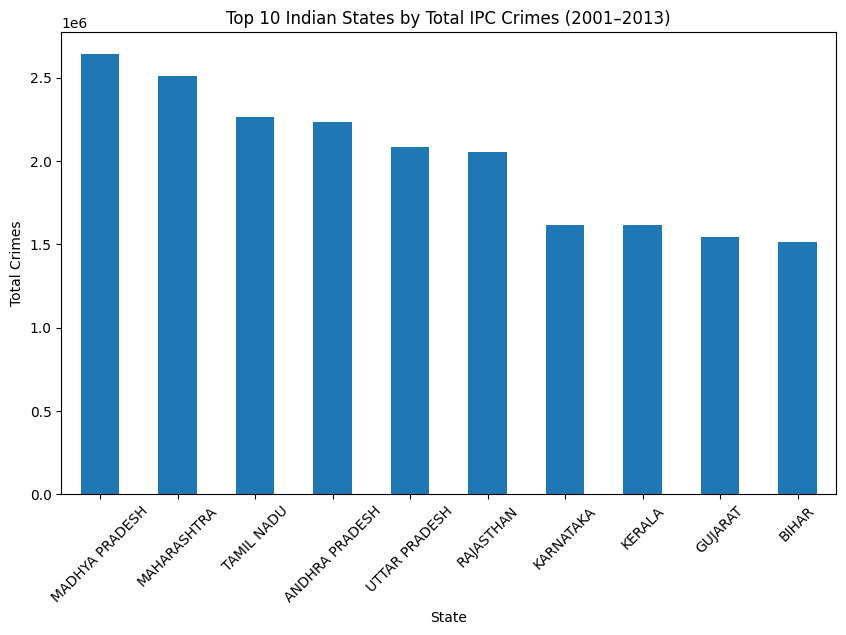

In [160]:
top_states = state_crime.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind="bar")

plt.title("Top 10 Indian States by Total IPC Crimes (2001–2013)")
plt.xlabel("State")
plt.ylabel("Total Crimes")

plt.xticks(rotation=45)

plt.show()

### Crime Trend Analysis (2001–2013)

The visualization shows the yearly total of IPC crimes across India.

Overall, crime levels display a gradual upward trend across the 13-year period. While small fluctuations occur in the early years, crime counts increase steadily after 2006 and reach their highest levels by 2013.

Several factors may contribute to this increase:

- Population growth
- Urbanization
- Improved crime reporting systems
- Greater public awareness leading to more reported cases

It is important to note that higher crime numbers do not always indicate worsening safety, as improved reporting mechanisms can also increase recorded crime counts.

In [161]:
year_crime = df_clean.groupby("YEAR")["TOTAL IPC CRIMES"].sum()
year_crime

YEAR
2001    1769308
2002    1780330
2003    1716120
2004    1832010
2005    1822602
2006    1878293
2007    1989673
2008    2093379
2009    2121345
2010    2224831
2011    2325575
2012    2387188
2013    2647722
Name: TOTAL IPC CRIMES, dtype: int64

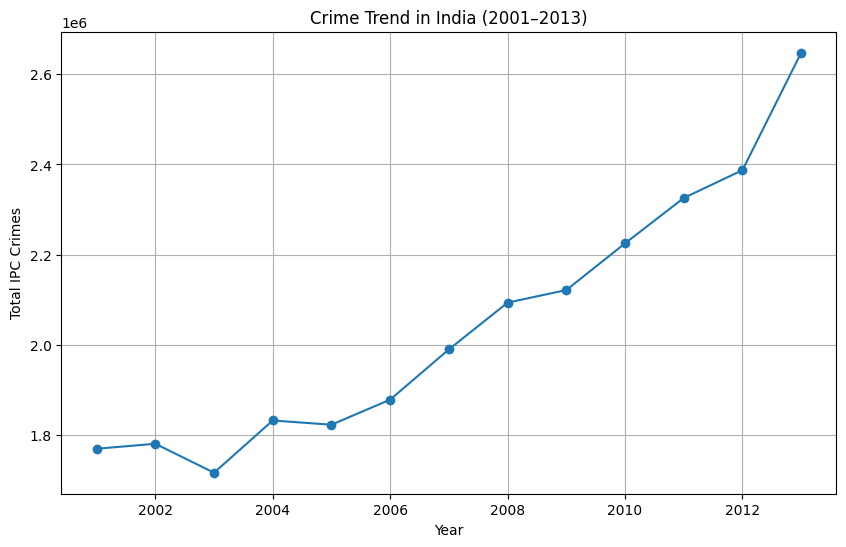

In [162]:
plt.figure(figsize=(10,6))
year_crime.plot(kind="line", marker="o")

plt.title("Crime Trend in India (2001–2013)")
plt.xlabel("Year")
plt.ylabel("Total IPC Crimes")
plt.grid(True)

plt.show()

### Crime Category Analysis

This section examines the distribution of different crime categories across India between 2001 and 2013.

By aggregating crime counts across all districts and years, we can identify which crime types occur most frequently.

Property-related crimes such as **theft** and **auto theft** dominate the dataset. These crimes are more common in densely populated urban areas where economic activity and mobility are higher.

The category **"Other IPC Crimes"** appears largest because it groups together several smaller offence categories under a single heading.

In comparison, violent crimes such as **murder**, **rape**, and **attempt to murder** represent a much smaller proportion of total recorded crimes.

In [163]:
crime_types = df_clean.drop(columns=["STATE/UT", "DISTRICT", "YEAR", "TOTAL IPC CRIMES"]).sum()

crime_types.sort_values(ascending=False).head(10)

OTHER IPC CRIMES                       10895454
THEFT                                   3873152
HURT/GREVIOUS HURT                      3706545
OTHER THEFT                             2437092
AUTO THEFT                              1436060
BURGLARY                                1221740
CAUSING DEATH BY NEGLIGENCE             1113381
CRUELTY BY HUSBAND OR HIS RELATIVES      994067
CHEATING                                 874927
RIOTS                                    847053
dtype: int64

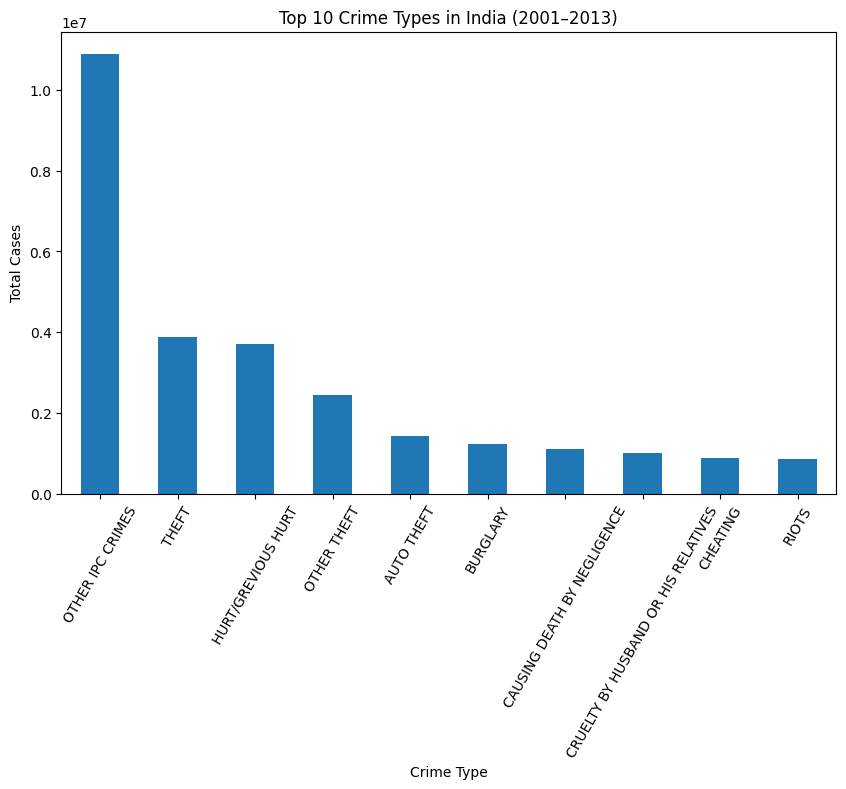

In [164]:
top_crimes = crime_types.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_crimes.plot(kind="bar")

plt.title("Top 10 Crime Types in India (2001–2013)")
plt.xlabel("Crime Type")
plt.ylabel("Total Cases")

plt.xticks(rotation=60)

plt.show()

### District Crime Analysis

The analysis shows that Bangalore Commissionerate recorded the highest number of IPC crimes between 2001 and 2013.

Large metropolitan areas dominate the list due to higher population density, greater economic activity, and improved crime reporting systems.

This does not necessarily indicate higher crime rates relative to population, but rather higher total recorded incidents.

In [165]:
district_crime = df_clean.groupby("DISTRICT")["TOTAL IPC CRIMES"].sum()

district_crime.sort_values(ascending=False).head(10)

DISTRICT
BANGALORE COMMR.    380665
MUMBAI COMMR.       257510
AHMEDABAD COMMR.    239263
INDORE              226647
HYDERABAD CITY      219286
KOLKATA             184748
BHOPAL              183502
CHENNAI             182214
PATNA               165844
CYBERABAD           161735
Name: TOTAL IPC CRIMES, dtype: int64

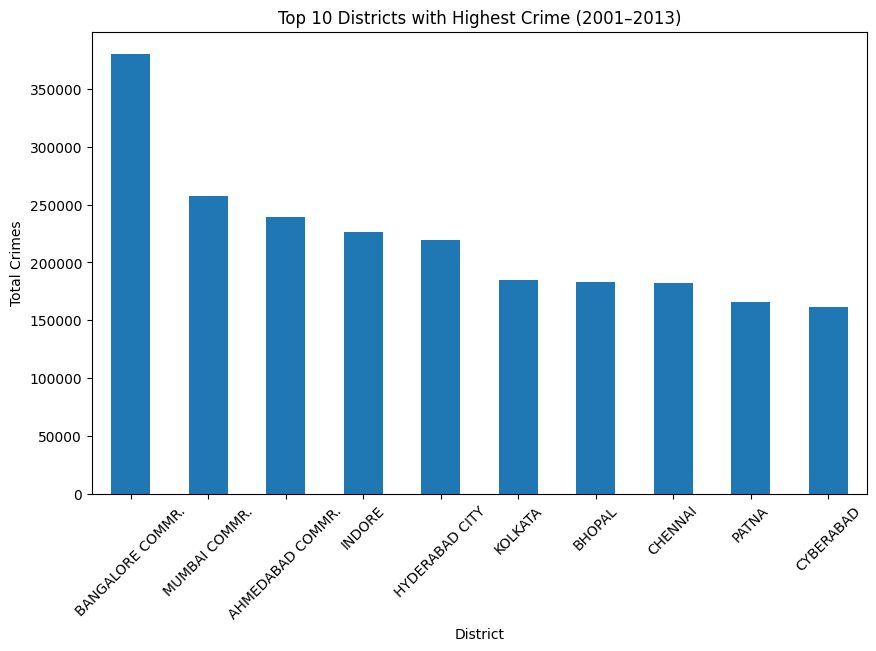

In [166]:
top_districts = district_crime.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_districts.plot(kind="bar")

plt.title("Top 10 Districts with Highest Crime (2001–2013)")
plt.xlabel("District")
plt.ylabel("Total Crimes")

plt.xticks(rotation=45)

plt.show()

## Crime Distribution by State Over Time

To better visualize how crime levels change across states over time, we create a heatmap.

Each row represents a state and each column represents a year. Darker colors indicate higher numbers of crimes.

This visualization helps highlight:

- States with consistently high crime levels
- Regions where crime increased over time
- Relative differences between states

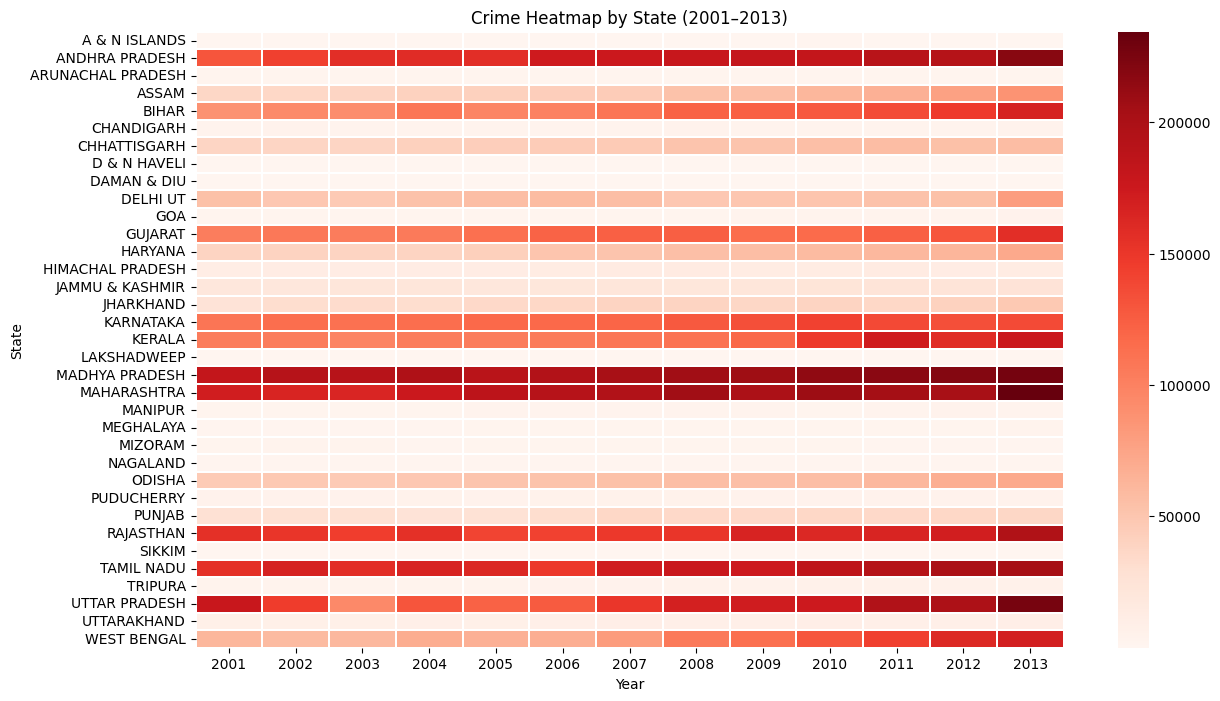

In [167]:

state_year = df_clean.groupby(["STATE/UT","YEAR"])["TOTAL IPC CRIMES"].sum().unstack()

plt.figure(figsize=(14,8))
sns.heatmap(state_year, cmap="Reds", linewidths = 0.3, linecolor = "white")

plt.title("Crime Heatmap by State (2001–2013)")
plt.xlabel("Year")
plt.ylabel("State")

plt.show()

In [168]:
df_clean["STATE/UT"].nunique()

35

In [169]:
df_clean.shape
df_clean.info()
df_clean.isnull().sum()

<class 'pandas.DataFrame'>
Index: 9385 entries, 0 to 9838
Data columns (total 33 columns):
 #   Column                                               Non-Null Count  Dtype
---  ------                                               --------------  -----
 0   STATE/UT                                             9385 non-null   str  
 1   DISTRICT                                             9385 non-null   str  
 2   YEAR                                                 9385 non-null   int64
 3   MURDER                                               9385 non-null   int64
 4   ATTEMPT TO MURDER                                    9385 non-null   int64
 5   CULPABLE HOMICIDE NOT AMOUNTING TO MURDER            9385 non-null   int64
 6   RAPE                                                 9385 non-null   int64
 7   CUSTODIAL RAPE                                       9385 non-null   int64
 8   OTHER RAPE                                           9385 non-null   int64
 9   KIDNAPPING & ABDUCTION  

STATE/UT                                               0
DISTRICT                                               0
YEAR                                                   0
MURDER                                                 0
ATTEMPT TO MURDER                                      0
CULPABLE HOMICIDE NOT AMOUNTING TO MURDER              0
RAPE                                                   0
CUSTODIAL RAPE                                         0
OTHER RAPE                                             0
KIDNAPPING & ABDUCTION                                 0
KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS            0
KIDNAPPING AND ABDUCTION OF OTHERS                     0
DACOITY                                                0
PREPARATION AND ASSEMBLY FOR DACOITY                   0
ROBBERY                                                0
BURGLARY                                               0
THEFT                                                  0
AUTO THEFT                     

In [170]:
crime_columns = df_clean.columns.drop(
    ["STATE/UT","DISTRICT","YEAR","TOTAL IPC CRIMES"]
)

crime_2001 = df_clean[df_clean["YEAR"] == 2001][crime_columns].sum()
crime_2013 = df_clean[df_clean["YEAR"] == 2013][crime_columns].sum()

crime_growth = (crime_2013 - crime_2001).sort_values(ascending=False)

crime_growth.head(10)

OTHER IPC CRIMES                                       391263
THEFT                                                  119819
AUTO THEFT                                             101977
CRUELTY BY HUSBAND OR HIS RELATIVES                     69696
HURT/GREVIOUS HURT                                      63182
CHEATING                                                62603
CAUSING DEATH BY NEGLIGENCE                             54335
KIDNAPPING & ABDUCTION                                  42974
KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS             37236
ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY     36615
dtype: int64

## Crime Growth Analysis

To understand which crimes have increased the most over time, we compare crime totals between 2001 and 2013.

By calculating the difference between these years, we can identify crime categories that experienced the largest growth during the period.

This provides insight into emerging crime trends and shifting patterns in criminal activity.

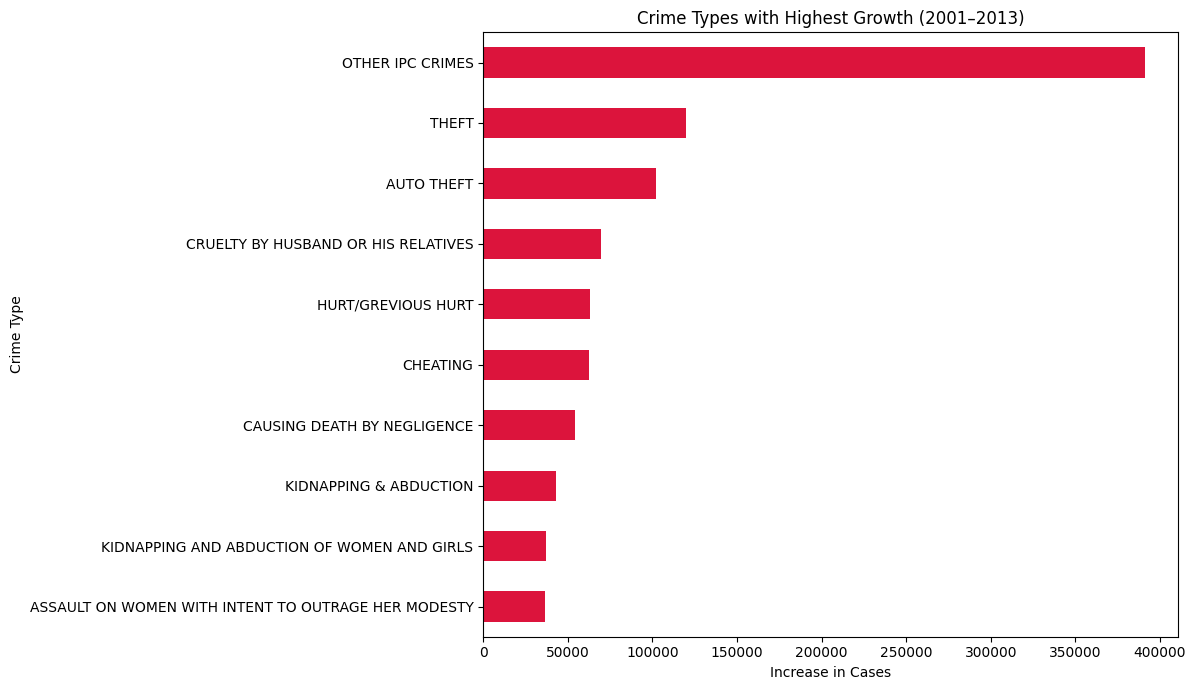

In [171]:
plt.figure(figsize=(12,7))

top_growth = crime_growth.sort_values(ascending=False).head(10)

top_growth.sort_values().plot(
    kind="barh",
    color="crimson"
)

plt.title("Crime Types with Highest Growth (2001–2013)")
plt.xlabel("Increase in Cases")
plt.ylabel("Crime Type")

plt.tight_layout()
plt.show()

## Conclusion

This analysis reveals several important insights into crime patterns in India between 2001 and 2013.

Key findings include:

- Crime levels increased steadily across the study period.
- Large states such as Madhya Pradesh, Maharashtra, and Tamil Nadu recorded the highest number of crimes.
- Property crimes such as theft dominate overall crime statistics.
- Major metropolitan districts report the highest crime totals due to population concentration and economic activity.
- Certain crime categories experienced significant growth between 2001 and 2013.

Further analysis could incorporate population-adjusted crime rates, geographic mapping, or predictive modeling to better understand crime dynamics.

In [172]:
df_clean.to_csv("../data/cleaned/clean_crime_data.csv", index=False)